In [2]:
from PIL import Image
import random
import cv2
import numpy as np
from blur_detector import detectBlur
import matplotlib.pyplot as plt

Before inserting Data:  [124 136 226]


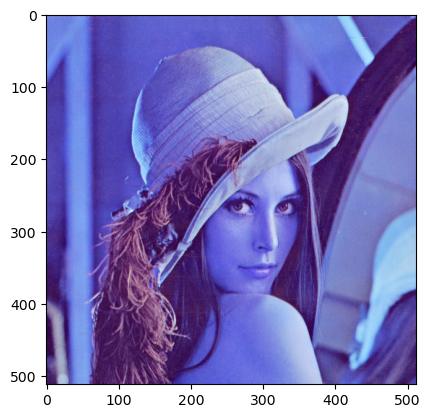

In [3]:
img_color=cv2.imread("Blur_steg_lenna.png")
plt.imshow(img_color)
# b,g,r=cv2.split(img_color)

print("Before inserting Data: ",img_color[1,0])

In [4]:
width=img_color.shape[0]
height=img_color.shape[1]
# print(width)
pixel=width*height*3
# print(pixel)

In [5]:
img_index=cv2.imread("lenna.png")
# plt.imshow(img_color)
b,g,r=cv2.split(img_index)

blue=True
# blue=False

green=True
# green=False

red=True

is_blurry_b=detectBlur(b)
blur_b=[]
if is_blurry_b.all():
    blur_b.append(is_blurry_b)
    print("\n")

    pos_index=[]
    new_blur_b=np.array(blur_b).flatten()
    # less_b=np.less(new_blur_b,0.1)
    # print(*less_b)
    for index,i in enumerate(new_blur_b):
        blur=np.less(i,0.1)
        if blur.all():
            pos_index.append(index)
    print(pos_index)
        


lsb_bin=[]
for i in range(3):
    for px in pos_index:
        row=px//width%width
        col=px%height
        npx=img_color[row,col,0]
        npx_bin=format(npx,'08b')
        lsb_npx=npx_bin[7:]
        lsb_bin.append(lsb_npx)
        
    for px in pos_index:
        row=px//width%width
        col=px%height
        npx=img_color[row,col,1]
        npx_bin=format(npx,'08b')
        lsb_npx=npx_bin[7:]
        lsb_bin.append(lsb_npx)
    for px in pos_index:
        row=px//width%width
        col=px%height
        npx=img_color[row,col,2]
        npx_bin=format(npx,'08b')

        lsb_npx=npx_bin[7:]
        lsb_bin.append(lsb_npx)

print(lsb_bin)
            

for i in range(0, len(lsb_bin)):
    lsb_bin[i] = int(lsb_bin[i]) 
data = np.packbits(lsb_bin)
print(data)
print("\n\n")
            

[|                  ] 10%
[| |                ] 20%
[| | |              ] 30%
[| | | |            ] 40%
[| | | | |          ] 50%
[| | | | | |        ] 60%
[| | | | | | |      ] 70%
[| | | | | | | |    ] 80%
[| | | | | | | | |  ] 90%


C:\Users\USER\anaconda3\lib\site-packages\blur_detector\__init__.py:103: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return(entropy(img, square(self.entropy_filt_kernel_sze)))




[0, 1, 2, 3, 4, 5, 6, 512, 513, 514, 515, 516, 517, 518, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2560, 2561, 2562, 2563, 2564, 2565, 2566, 3072, 3073, 3074, 3075, 3076, 3077, 157696, 157697, 157698, 157699, 157700, 158208, 158209, 158210, 158211, 158212, 158213, 158720, 158721, 158722, 158723, 158724, 158725, 159232, 159233, 159234, 159235, 159236, 159237, 159744, 159745, 159746, 159747, 159748, 159749, 160256, 160257, 160258, 160259, 160260, 160261, 160768, 160769, 160770, 160771, 160772, 160773, 161280, 161281, 161282, 161283, 161284, 161285, 161792, 161793, 161794, 161795, 161796, 161797, 162304, 162305, 162306, 162307, 162308, 162309, 162816, 162817, 162818, 162819, 162820, 162821, 163328, 163329, 163330, 163331, 163332, 163333, 163840, 163841, 163842, 163843, 163844, 163845, 164352, 164353, 164354, 164355, 164356, 164357, 164864, 164865, 164866, 164867, 164868, 164869, 165376, 165377, 165378, 1

In [6]:
decode=""
for char in data:
    p_char = chr(char)
    decode+=p_char
    if not decode.isprintable():
        break
print("Decoded Message:",decode)

Decoded Message: HelloWorldHelloWorldHelloWorld 
